<a href="https://colab.research.google.com/github/muthyalasairam6/ML-PROJECTS/blob/main/STUDENT_MENTALHEALTH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Student Mental health.csv")

df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [ ]:
print(df.shape)

df.info()

df.isnull().sum()

(101, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic attack?                     101 non-n

,0
Timestamp,0
Choose your gender,0
Age,1
What is your course?,0
Your current year of Study,0
What is your CGPA?,0
Marital status,0
Do you have Depression?,0
Do you have Anxiety?,0
Do you have Panic attack?,0


In [ ]:
# Numerical column
df['Age'] = df['Age'].fillna(df['Age'].median())

# Categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.drop("Timestamp", axis=1, inplace=True)

In [ ]:
df['Do you have Depression?'] = df['Do you have Depression?'].map({
    'Yes':1,
    'No':0
})

In [ ]:
X = df.drop([
    'Do you have Depression?',
    'Do you have Anxiety?',
    'Do you have Panic attack?'
], axis=1)

y = df['Do you have Depression?']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_dict = {}

for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        le_dict[col] = le

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train_scaled, y_train)

SVC()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(100,50),
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))

In [ ]:
evaluate_model(lr, X_test_scaled, y_test)

Accuracy : 0.8571428571428571
Precision: 1.0
Recall   : 0.5714285714285714
F1 Score : 0.7272727272727273


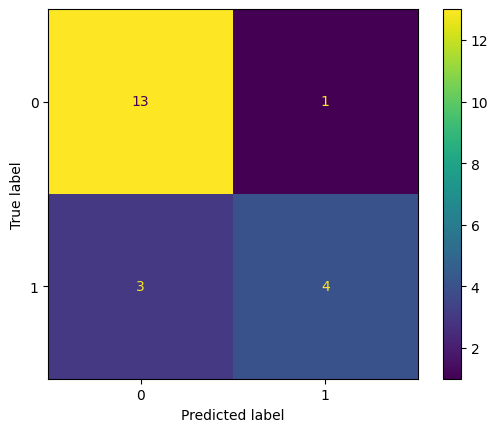

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

In [ ]:
results = pd.DataFrame(
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results

,Model,Accuracy,Precision,Recall,F1 Score


In [ ]:
import joblib

joblib.dump(rf, "student_mental_health_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
student_data = {
    "Age":20,
    "Gender":1,
    "Academic_Pressure":4,
    "Study_Hours":8,
    "Sleep_Hours":5,
    "Financial_Stress":3,
    "Social_Support":2
}

In [ ]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
ConfusionMatrixDisplay   type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
KNeighborsClassifier     ABCMeta                   <class 'sklearn.neighbors<...>on.KNeighborsClassifier'>
LabelEncoder             type                      <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
MLPClassifier            ABCMeta                   <class 'sklearn.neural_ne<...>erceptron.MLPClassifier'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SVC                      ABCMeta                   <class 'sklearn.svm._classes.SVC'>
StandardScaler           type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                        DataFrame         

In [ ]:
print(student_data)

{'Age': 20, 'Gender': 1, 'Academic_Pressure': 4, 'Study_Hours': 8, 'Sleep_Hours': 5, 'Financial_Stress': 3, 'Social_Support': 2}


In [ ]:
student_data = {
    "Age": 20,
    "Gender": 1,
    "Academic_Pressure": 4,
    "Study_Hours": 8,
    "Sleep_Hours": 5,
    "Financial_Stress": 3,
    "Social_Support": 2
}

In [ ]:
input_data = [list(student_data.values())]

In [ ]:
input_scaled = scaler.transform(input_data)

prediction = model.predict(input_scaled)

print(prediction)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
def analyze_risk(prediction):

    if prediction == 0:
        return "Healthy"

    elif prediction == 1:
        return "Mild Risk"

    elif prediction == 2:
        return "Moderate Risk"

    else:
        return "High Risk"

In [ ]:
def generate_recommendation(risk):

    recommendations = {

        "Healthy":[
            "Maintain current lifestyle",
            "Exercise regularly",
            "Sleep 7-8 hours"
        ],

        "Mild Risk":[
            "Take regular breaks",
            "Practice meditation",
            "Talk with friends"
        ],

        "Moderate Risk":[
            "Reduce academic pressure",
            "Seek counseling support",
            "Improve sleep schedule"
        ],

        "High Risk":[
            "Contact mental health counselor",
            "Immediate wellness intervention",
            "Schedule professional support"
        ]
    }

    return recommendations[risk]

In [ ]:
import pandas as pd

def save_record(student_id,risk):

    data = pd.DataFrame({
        "Student_ID":[student_id],
        "Risk_Level":[risk]
    })

    data.to_csv(
        "wellness_records.csv",
        mode="a",
        header=False,
        index=False
    )

In [ ]:
history = pd.read_csv("Student Mental health.csv")

history.tail()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
96,13/07/2020 19:56:49,Female,21.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
97,13/07/2020 21:21:42,Male,18.0,Engineering,Year 2,3.00 - 3.49,No,Yes,Yes,No,No
98,13/07/2020 21:22:56,Female,19.0,Nursing,Year 3,3.50 - 4.00,Yes,Yes,No,Yes,No
99,13/07/2020 21:23:57,Female,23.0,Pendidikan Islam,year 4,3.50 - 4.00,No,No,No,No,No
100,18/07/2020 20:16:21,Male,20.0,Biomedical science,Year 2,3.00 - 3.49,No,No,No,No,No


In [ ]:
import joblib

joblib.dump(model,'model.pkl')
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [ ]:
import joblib

model = joblib.load('model.pkl')
scaler = joblib.load('scaler.pkl')

In [ ]:
def predict_mental_health(features):

    scaled = scaler.transform([features])

    prediction = model.predict(scaled)[0]

    return prediction

In [ ]:
def wellness_agent(student_id, features):

    pred = predict_mental_health(features)

    risk = analyze_risk(pred)

    recommendations = generate_recommendation(risk)

    save_record(student_id,risk)

    return {
        "Student_ID":student_id,
        "Risk_Level":risk,
        "Recommendations":recommendations
    }

In [ ]:
sample = [
    20,
    1,
    5,
    9,
    4,
    4,
    1
]

result = wellness_agent(
    "S101",
    sample
)

print(result)

{'Student_ID': 'S101', 'Risk_Level': 'Mild Risk', 'Recommendations': ['Take regular breaks', 'Practice meditation', 'Talk with friends']}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from textblob import TextBlob

text = "I feel stressed and unable to focus."

sentiment = TextBlob(text).sentiment.polarity

print(sentiment)

-0.5


In [ ]:
def calculate_score(probability):

    return round(probability * 100)

In [ ]:
print(history.columns)

Index(['Timestamp', 'Choose your gender', 'Age', 'What is your course?',
       'Your current year of Study', 'What is your CGPA?', 'Marital status',
       'Do you have Depression?', 'Do you have Anxiety?',
       'Do you have Panic attack?',
       'Did you seek any specialist for a treatment?'],
      dtype='object')


In [ ]:
print("Columns:")
print(history.columns.tolist())

print("\nData:")
print(history.head())

Columns:
['Timestamp', 'Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?', 'Marital status', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Did you seek any specialist for a treatment?']

Data:
        Timestamp Choose your gender   Age What is your course?  \
0  8/7/2020 12:02             Female  18.0          Engineering   
1  8/7/2020 12:04               Male  21.0    Islamic education   
2  8/7/2020 12:05               Male  19.0                  BIT   
3  8/7/2020 12:06             Female  22.0                 Laws   
4  8/7/2020 12:13               Male  23.0         Mathemathics   

  Your current year of Study What is your CGPA? Marital status  \
0                     year 1        3.00 - 3.49             No   
1                     year 2        3.00 - 3.49             No   
2                     Year 1        3.00 - 3.49             No   
3                     year 3        3.00 - 3.49     

In [ ]:
print(history.columns.tolist())

['Timestamp', 'Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?', 'Marital status', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Did you seek any specialist for a treatment?']


In [ ]:
pip install streamlit joblib pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 60.6 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import pandas as pd
import joblib
import os

# Load model
model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

st.set_page_config(
    page_title="Student Wellness Agent",
    layout="wide"
)

st.title("🎓 AI Student Wellness Agent")

st.write("Mental Health Depression Prediction System")

# Inputs

gender = st.selectbox(
    "Gender",
    ["Male", "Female"]
)

age = st.number_input(
    "Age",
    min_value=18,
    max_value=35,
    value=20
)

course = st.selectbox(
    "Course",
    [
        "Engineering",
        "BIT",
        "BCS",
        "Laws",
        "Mathemathics",
        "Islamic education"
    ]
)

year = st.selectbox(
    "Year of Study",
    [
        "year 1",
        "year 2",
        "year 3",
        "year 4"
    ]
)

cgpa = st.selectbox(
    "CGPA",
    [
        "0 - 1.99",
        "2.00 - 2.49",
        "2.50 - 2.99",
        "3.00 - 3.49",
        "3.50 - 4.00"
    ]
)

marital = st.selectbox(
    "Marital Status",
    ["Yes", "No"]
)

treatment = st.selectbox(
    "Specialist Treatment",
    ["Yes", "No"]
)

student_id = st.text_input("Student ID")

if st.button("Predict"):

    # Manual encoding
    gender_map = {"Male": 1, "Female": 0}
    marital_map = {"Yes": 1, "No": 0}
    treatment_map = {"Yes": 1, "No": 0}

    input_data = pd.DataFrame({
        "Choose your gender":[gender_map[gender]],
        "Age":[age],
        "What is your course?":[0],
        "Your current year of Study":[0],
        "What is your CGPA?":[0],
        "Marital status":[marital_map[marital]],
        "Did you seek any specialist for a treatment?":[treatment_map[treatment]]
    })

    input_scaled = scaler.transform(input_data)

    prediction = model.predict(input_scaled)[0]

    if prediction == 0:
        risk = "Healthy"
        recommendations = [
            "Maintain healthy lifestyle",
            "Exercise regularly",
            "Sleep 7-8 hours"
        ]
    else:
        risk = "Mild Risk"
        recommendations = [
            "Practice meditation",
            "Reduce academic stress",
            "Seek counseling support"
        ]

    st.success(f"Prediction: {risk}")

    st.subheader("Recommendations")

    for rec in recommendations:
        st.write("✅", rec)

    record = pd.DataFrame({
        "Student_ID":[student_id],
        "Risk_Level":[risk]
    })

    file_name = "wellness_records.csv"

    if os.path.exists(file_name):
        record.to_csv(
            file_name,
            mode="a",
            header=False,
            index=False
        )
    else:
        record.to_csv(
            file_name,
            index=False
        )

# Display records

if os.path.exists("wellness_records.csv"):

    st.subheader("Student Records")

    history = pd.read_csv(
        "wellness_records.csv"
    )

    st.dataframe(history)

2026-06-23 16:44:31.786 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 16:44:31.788 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 16:44:31.938 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-23 16:44:31.942 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 16:44:31.943 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 16:44:31.945 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 16:44:31.946 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [ ]:
%%writefile app.py
# paste complete code here

Writing app.py


In [ ]:
!streamlit run app.py



2026-06-23 16:50:41.534 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.221.140:8501

